In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('loan_dataset.csv')
df.shape

(75000, 32)

In [9]:
df.head(3)


,Customer_ID,Age,Gender,Marital_Status,Education,Employment_Type,Occupation,Monthly_Salary,Annual_Income,City,...,Vehicle_Ownership,CIBIL_Score,Savings_Balance,Transaction_History_Score,Repayment_History,EMI_to_Income_Ratio,Loan_Approval_Status,Default_Risk,Risk_Category,Processing_Time_Days
0,HDFC_PUNE_100000,59,Male,Married,Graduate,Self Employed,Freelancer,227892,2734704,Pune,...,Yes,714,NaN,63.0,Average,0.49,Conditional,Medium,Medium Risk,8
1,HDFC_PUNE_100001,48,Female,Divorced,Graduate,Government,Officer,201845,2422140,Pune,...,Yes,754,670987.0,64.0,Poor,0.06,Conditional,High,High Risk,6
2,HDFC_PUNE_100002,55,Male,Married,Graduate,Self Employed,Freelancer,39457,473484,Pune,...,No,553,228165.0,75.0,Good,0.20,Rejected,High,High Risk,18


In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education',
       'Employment_Type', 'Occupation', 'Monthly_Salary', 'Annual_Income',
       'City', 'Area_Type', 'Credit_Score', 'Existing_Loan_Count',
       'Existing_EMI', 'Bank_Account_Type', 'Years_With_Bank', 'Loan_Type',
       'Loan_Amount', 'Interest_Rate', 'EMI', 'Loan_Tenure_Years',
       'Property_Ownership', 'Vehicle_Ownership', 'CIBIL_Score',
       'Savings_Balance', 'Transaction_History_Score', 'Repayment_History',
       'EMI_to_Income_Ratio', 'Loan_Approval_Status', 'Default_Risk',
       'Risk_Category', 'Processing_Time_Days'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                75000 non-null  str    
 1   Age                        75000 non-null  int64  
 2   Gender                     75000 non-null  str    
 3   Marital_Status             75000 non-null  str    
 4   Education                  75000 non-null  str    
 5   Employment_Type            75000 non-null  str    
 6   Occupation                 75000 non-null  str    
 7   Monthly_Salary             75000 non-null  int64  
 8   Annual_Income              75000 non-null  int64  
 9   City                       75000 non-null  str    
 10  Area_Type                  75000 non-null  str    
 11  Credit_Score               75000 non-null  int64  
 12  Existing_Loan_Count        75000 non-null  int64  
 13  Existing_EMI               73570 non-null  float64
 14  B

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,75000.0,4.006423e+01,1.127494e+01,21.00,30.0000,40.00,5.000000e+01,59.00
Monthly_Salary,75000.0,1.240065e+05,8.953504e+04,2.00,60747.5000,111845.50,1.632038e+05,499939.00
Annual_Income,75000.0,1.488078e+06,1.074420e+06,24.00,728970.0000,1342146.00,1.958445e+06,5999268.00
Credit_Score,75000.0,7.268655e+02,8.550884e+01,500.00,669.0000,733.00,7.920000e+02,899.00
Existing_Loan_Count,75000.0,1.310733e+00,1.142131e+00,0.00,0.0000,1.00,2.000000e+00,4.00
Existing_EMI,73570.0,3.095733e+04,3.130832e+04,0.00,8438.2500,21910.50,4.422450e+04,248129.00
Years_With_Bank,75000.0,9.998853e+00,5.467879e+00,1.00,5.0000,10.00,1.500000e+01,19.00
Loan_Amount,75000.0,2.110816e+06,2.340709e+06,50035.00,569783.2500,1140410.50,2.455897e+06,8999957.00
Interest_Rate,75000.0,1.248362e+01,3.152040e+00,8.00,10.3100,11.94,1.355000e+01,22.00
EMI,75000.0,3.284752e+04,2.295902e+04,1310.51,16244.6675,26679.66,4.303241e+04,138031.05


In [13]:
df.isna().sum()

Customer_ID                     0
Age                             0
Gender                          0
Marital_Status                  0
Education                       0
Employment_Type                 0
Occupation                      0
Monthly_Salary                  0
Annual_Income                   0
City                            0
Area_Type                       0
Credit_Score                    0
Existing_Loan_Count             0
Existing_EMI                 1430
Bank_Account_Type               0
Years_With_Bank                 0
Loan_Type                       0
Loan_Amount                     0
Interest_Rate                   0
EMI                             0
Loan_Tenure_Years               0
Property_Ownership              0
Vehicle_Ownership               0
CIBIL_Score                     0
Savings_Balance              1481
Transaction_History_Score     767
Repayment_History               0
EMI_to_Income_Ratio             0
Loan_Approval_Status            0
Default_Risk  

In [32]:
df.drop(columns=['Customer_ID'], inplace=True)

In [15]:
df[['Savings_Balance', 'Existing_EMI']].head()

,Savings_Balance,Existing_EMI
0,NaN,112727.0
1,670987.0,11394.0
2,228165.0,7989.0
3,485754.0,2568.0
4,1044577.0,70592.0


In [19]:
num_cols = df.select_dtypes(include=['int64','float64'])
num_cols.head()

,Age,Monthly_Salary,Annual_Income,Credit_Score,Existing_Loan_Count,Existing_EMI,Years_With_Bank,Loan_Amount,Interest_Rate,EMI,Loan_Tenure_Years,CIBIL_Score,Savings_Balance,Transaction_History_Score,EMI_to_Income_Ratio,Processing_Time_Days
0,59,227892,2734704,714,0,112727.0,8,1547617,10.73,29243.89,6,714,NaN,63.0,0.49,8
1,48,201845,2422140,754,4,11394.0,7,4295513,10.06,43114.33,18,754,670987.0,64.0,0.06,6
2,55,39457,473484,553,1,7989.0,18,585822,18.56,17380.42,4,553,228165.0,75.0,0.20,18
3,44,56044,672528,684,0,2568.0,12,886146,12.42,29610.81,3,684,485754.0,56.0,0.05,2
4,54,143684,1724208,713,3,70592.0,15,915270,12.09,20401.33,5,713,1044577.0,94.0,0.49,11


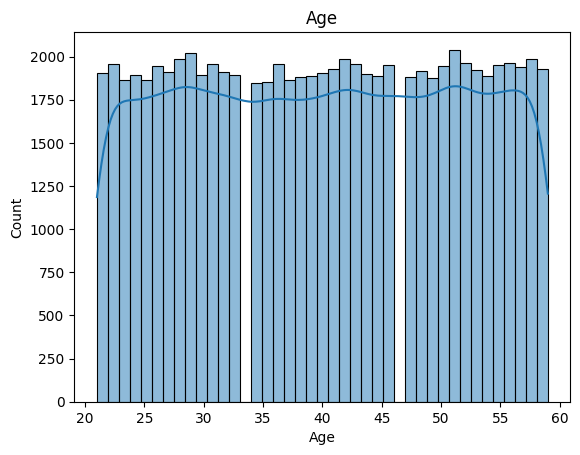

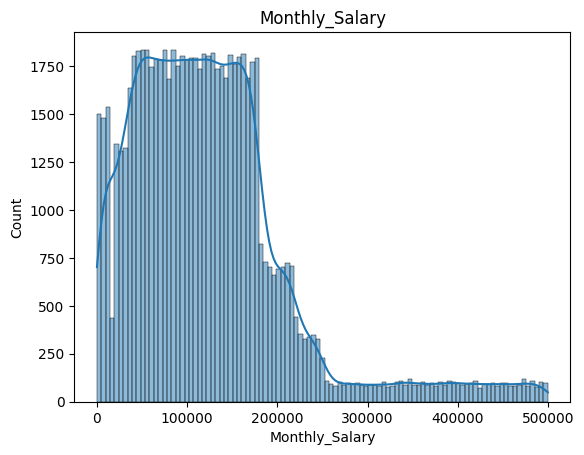

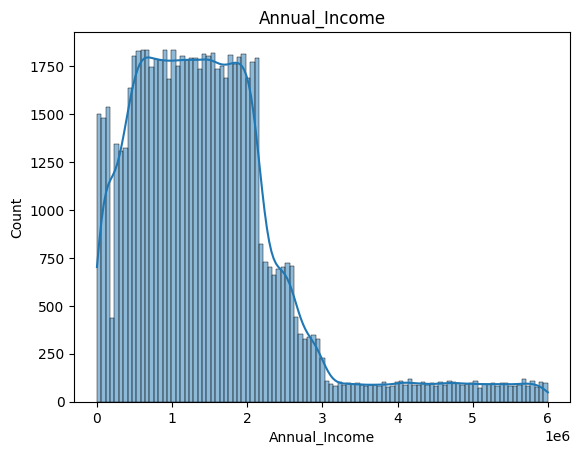

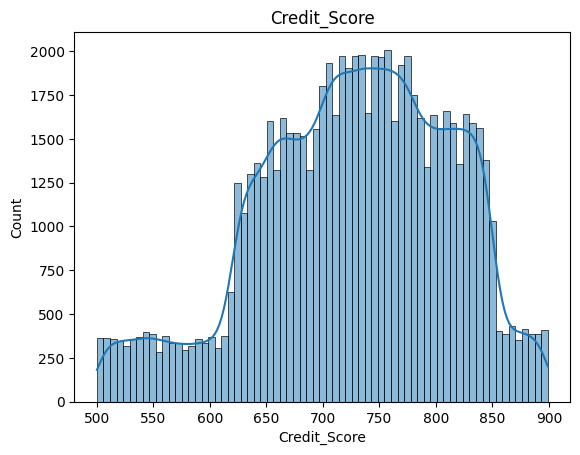

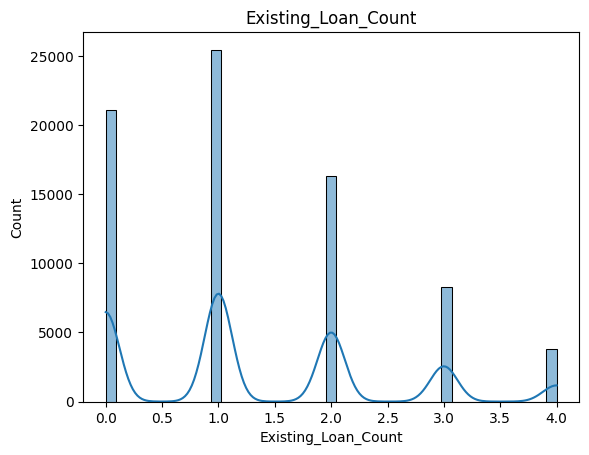

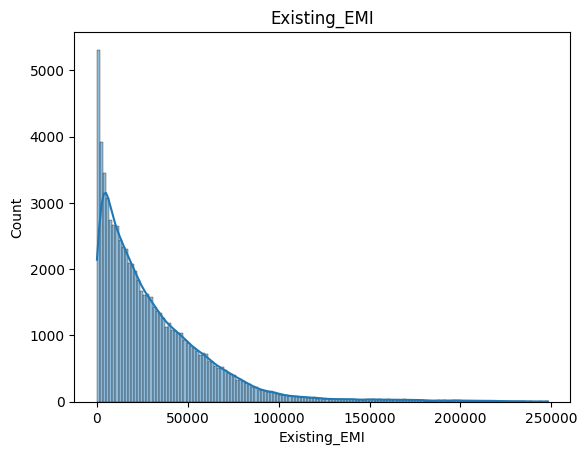

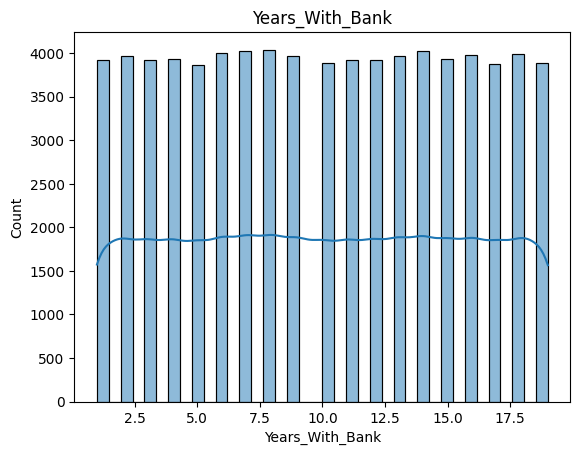

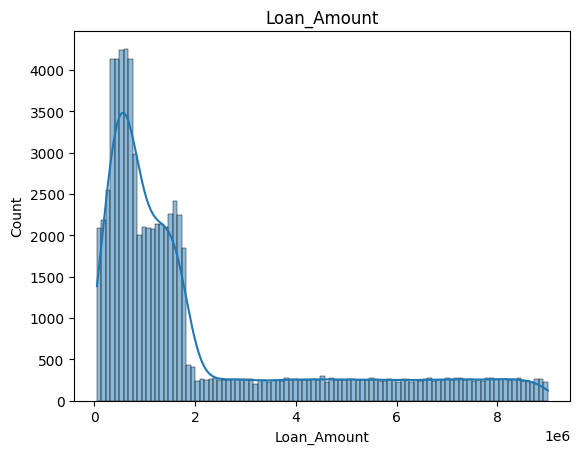

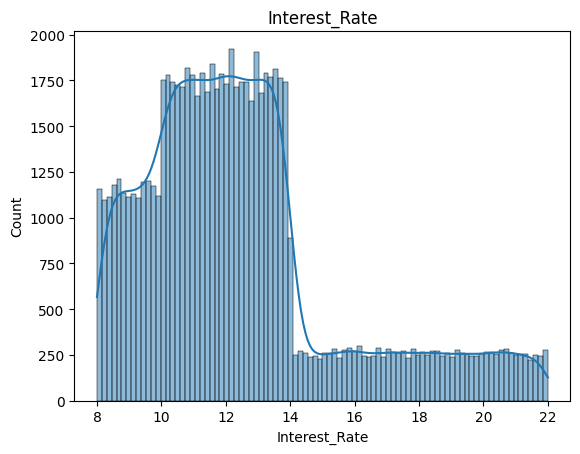

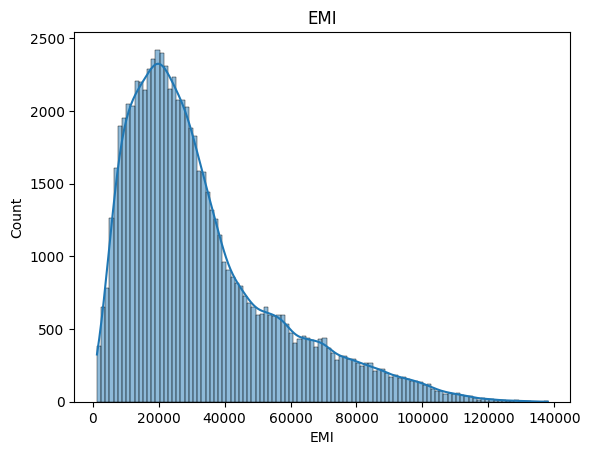

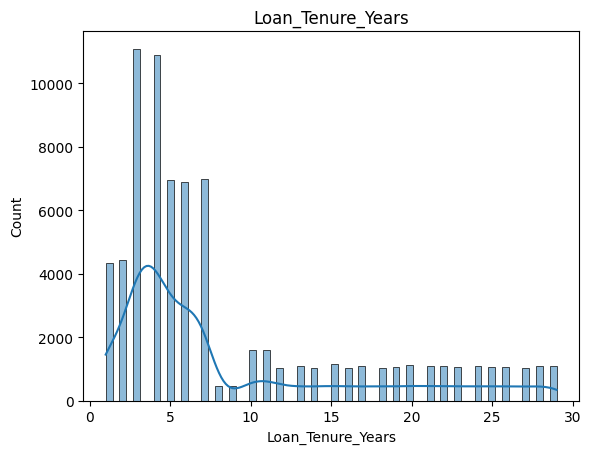

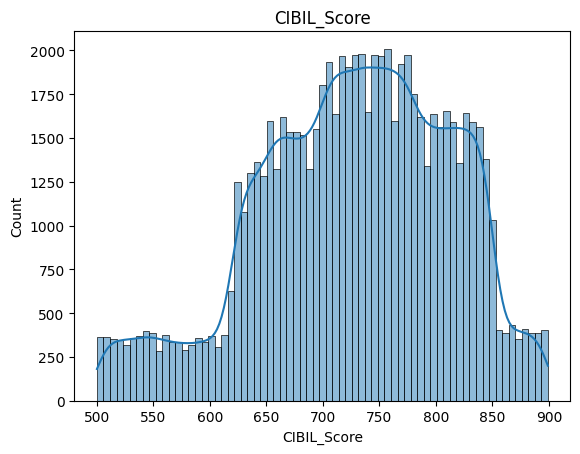

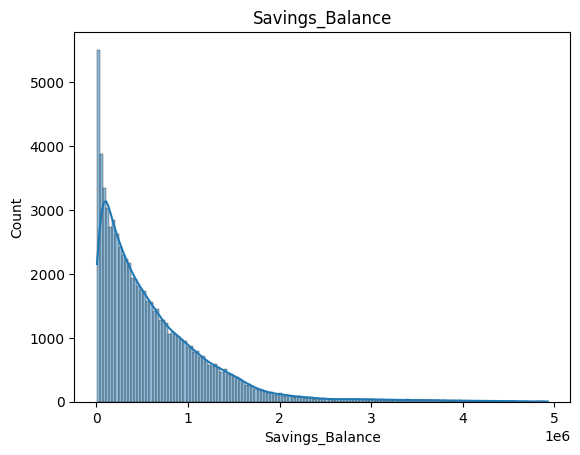

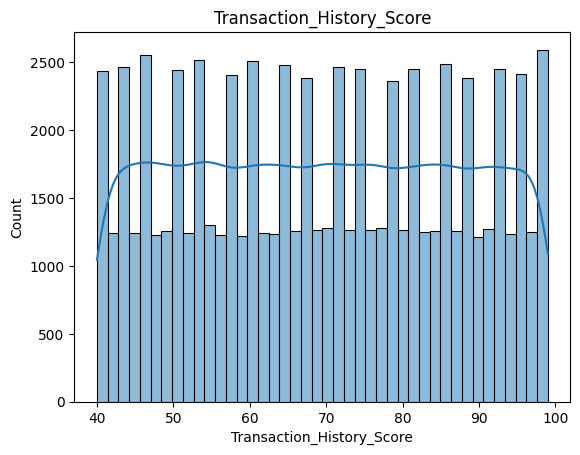

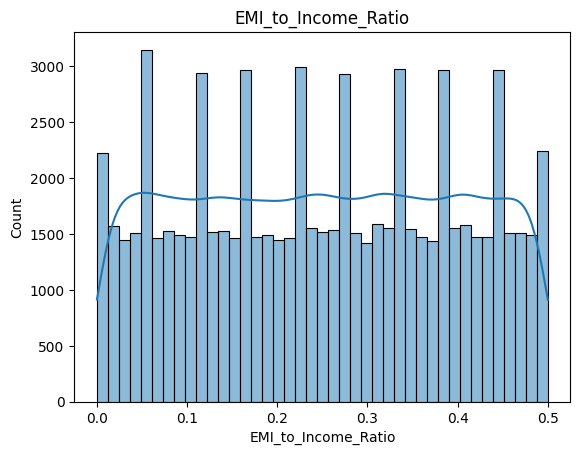

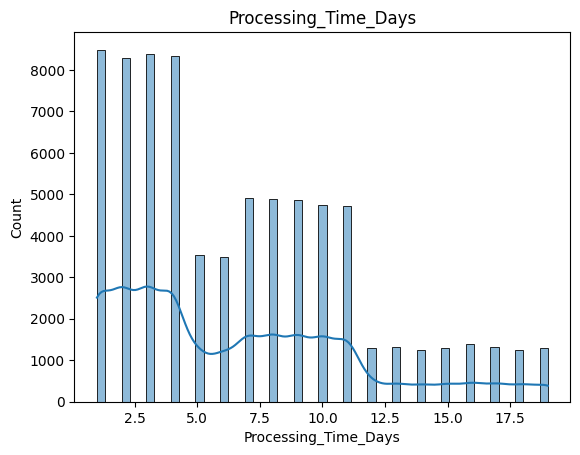

In [20]:
for col in num_cols:
    sns.histplot(num_cols[col],kde=True)
    plt.title(col)
    plt.show()

In [21]:
num_cols.isna().sum()

Age                             0
Monthly_Salary                  0
Annual_Income                   0
Credit_Score                    0
Existing_Loan_Count             0
Existing_EMI                 1430
Years_With_Bank                 0
Loan_Amount                     0
Interest_Rate                   0
EMI                             0
Loan_Tenure_Years               0
CIBIL_Score                     0
Savings_Balance              1481
Transaction_History_Score     767
EMI_to_Income_Ratio             0
Processing_Time_Days            0
dtype: int64

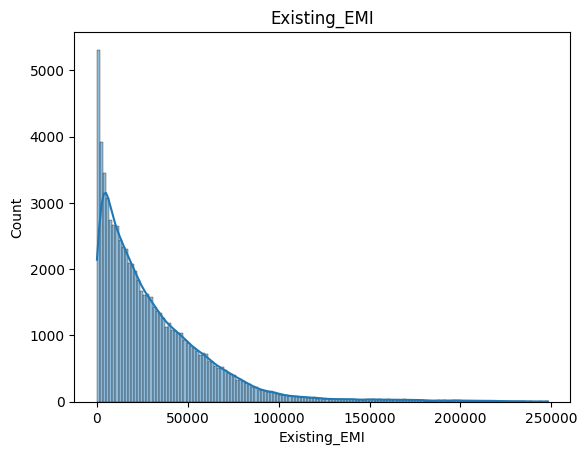

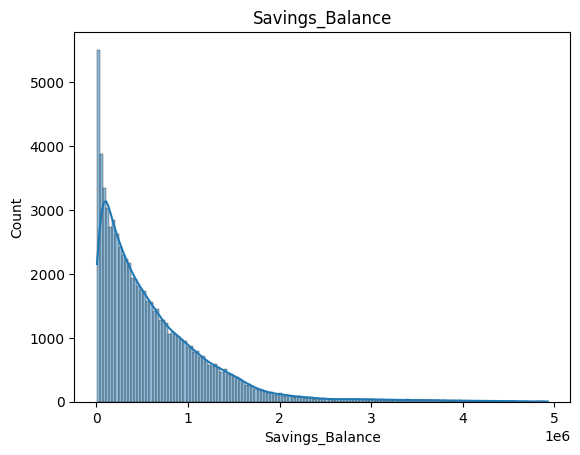

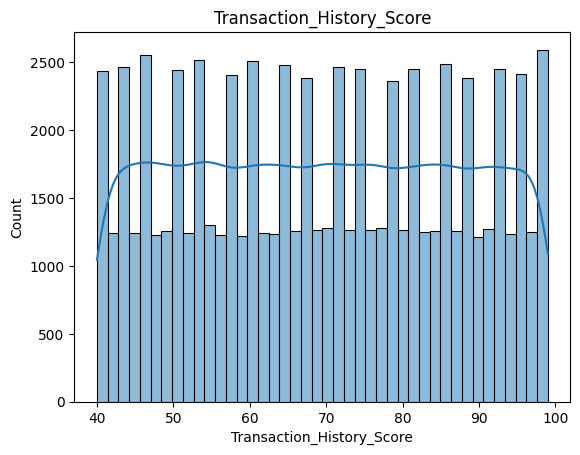

In [22]:
null_cols = df[['Existing_EMI','Savings_Balance','Transaction_History_Score']]
for col in null_cols:
    sns.histplot(null_cols[col],kde=True)
    plt.title(col)
    plt.show()

In [24]:
null_cols.skew()

Existing_EMI                 2.109973
Savings_Balance              2.125315
Transaction_History_Score    0.004856
dtype: float64

In [26]:
# ============================================================
# HANDLE NULL VALUES BASED ON SKEWNESS
# ============================================================

# Existing EMI → Median

df['Existing_EMI']=df['Existing_EMI'].fillna(
    df['Existing_EMI'].median(),
    inplace=True
)

# Savings Balance → Median

df['Savings_Balance']=df['Savings_Balance'].fillna(
    df['Savings_Balance'].median(),
    inplace=True
)

# Transaction History Score → Mean

df['Transaction_History_Score']=df['Transaction_History_Score'].fillna(
    df['Transaction_History_Score'].mean(),
    inplace=True
)

# Final Check

print(df.isnull().sum())

Customer_ID                  0
Age                          0
Gender                       0
Marital_Status               0
Education                    0
Employment_Type              0
Occupation                   0
Monthly_Salary               0
Annual_Income                0
City                         0
Area_Type                    0
Credit_Score                 0
Existing_Loan_Count          0
Existing_EMI                 0
Bank_Account_Type            0
Years_With_Bank              0
Loan_Type                    0
Loan_Amount                  0
Interest_Rate                0
EMI                          0
Loan_Tenure_Years            0
Property_Ownership           0
Vehicle_Ownership            0
CIBIL_Score                  0
Savings_Balance              0
Transaction_History_Score    0
Repayment_History            0
EMI_to_Income_Ratio          0
Loan_Approval_Status         0
Default_Risk                 0
Risk_Category                0
Processing_Time_Days         0
dtype: i

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20864\4289438990.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Existing_EMI']=df['Existing_EMI'].fillna(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20864\4289438990.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

In [27]:
cat_cols = df.select_dtypes(include=['object'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20864\775259423.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object'])


In [28]:
import warnings
warnings.filterwarnings('ignore')

In [29]:
cat_cols.head()

,Customer_ID,Gender,Marital_Status,Education,Employment_Type,Occupation,City,Area_Type,Bank_Account_Type,Loan_Type,Property_Ownership,Vehicle_Ownership,Repayment_History,Loan_Approval_Status,Default_Risk,Risk_Category
0,HDFC_PUNE_100000,Male,Married,Graduate,Self Employed,Freelancer,Pune,Urban,Savings,Car Loan,Rented,Yes,Average,Conditional,Medium,Medium Risk
1,HDFC_PUNE_100001,Female,Divorced,Graduate,Government,Officer,Pune,Urban,Salary,Home Loan,Owned,Yes,Poor,Conditional,High,High Risk
2,HDFC_PUNE_100002,Male,Married,Graduate,Self Employed,Freelancer,Pune,Urban,Savings,Personal Loan,Family Owned,No,Good,Rejected,High,High Risk
3,HDFC_PUNE_100003,Male,Single,Graduate,Private,Analyst,Pune,Semi-Urban,Salary,Car Loan,Owned,Yes,Average,Approved,Medium,Medium Risk
4,HDFC_PUNE_100004,Male,Single,Graduate,Self Employed,Consultant,Pune,Semi-Urban,Savings,Car Loan,Rented,No,Average,Conditional,Medium,Medium Risk


In [30]:
cat_cols.isna().sum()

Customer_ID             0
Gender                  0
Marital_Status          0
Education               0
Employment_Type         0
Occupation              0
City                    0
Area_Type               0
Bank_Account_Type       0
Loan_Type               0
Property_Ownership      0
Vehicle_Ownership       0
Repayment_History       0
Loan_Approval_Status    0
Default_Risk            0
Risk_Category           0
dtype: int64

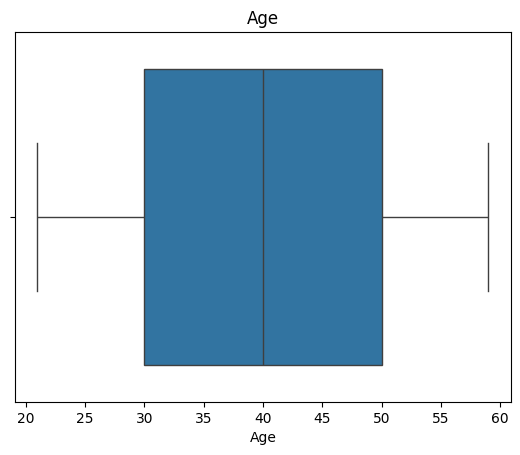

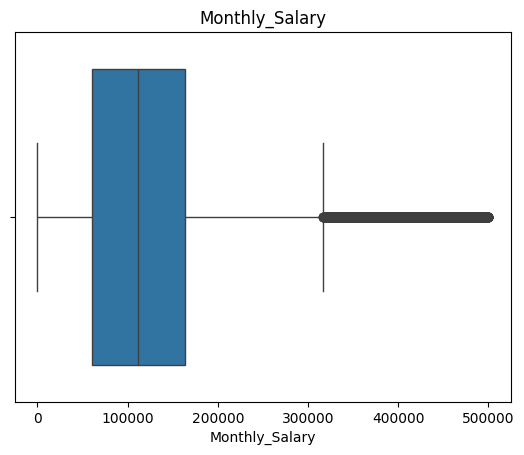

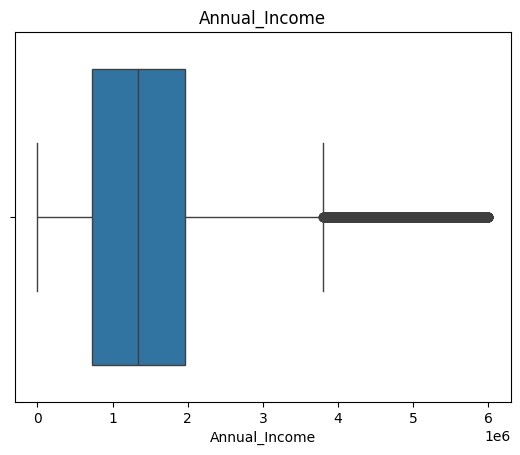

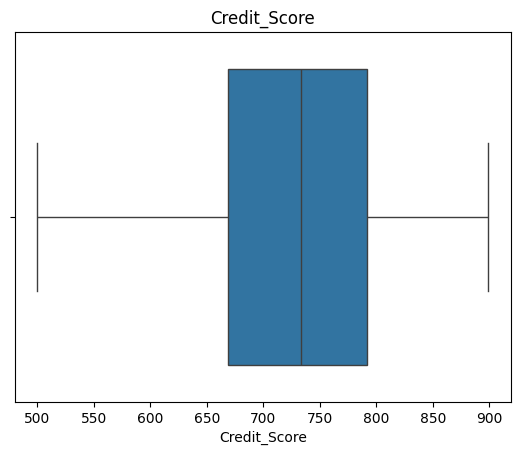

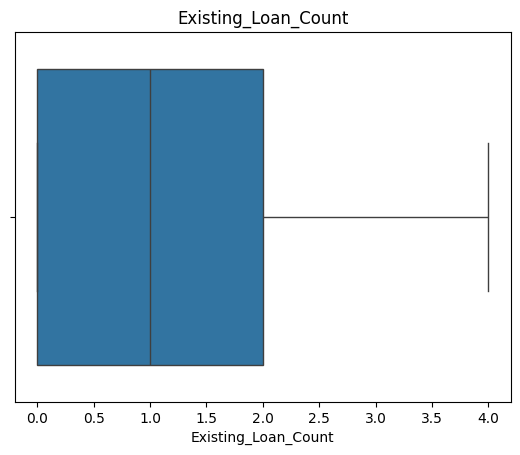

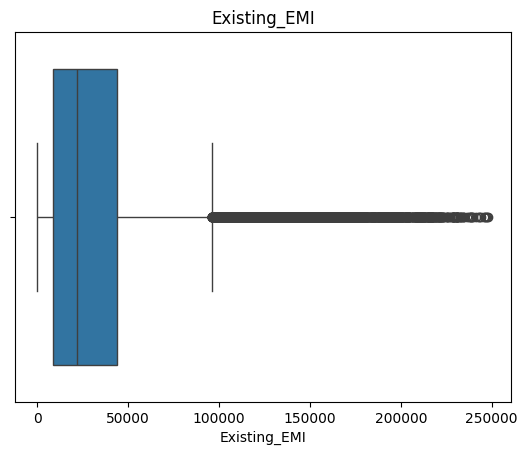

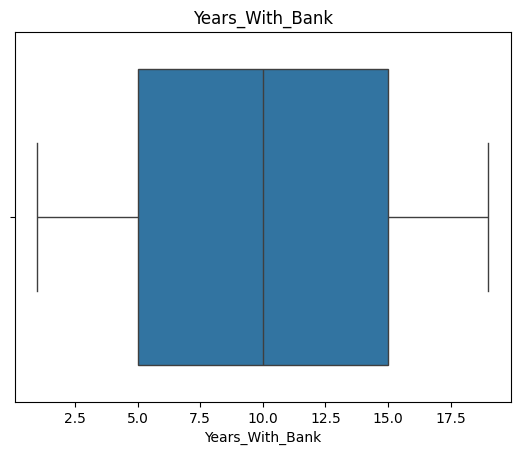

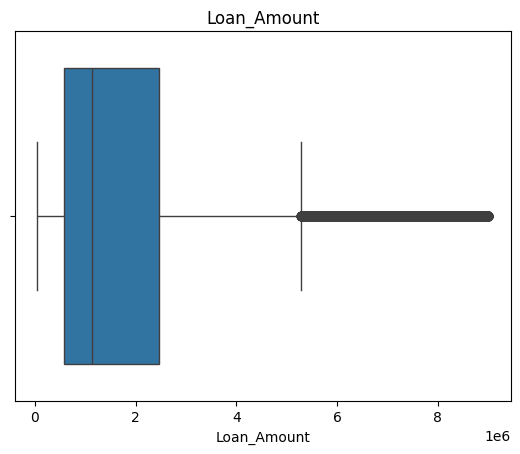

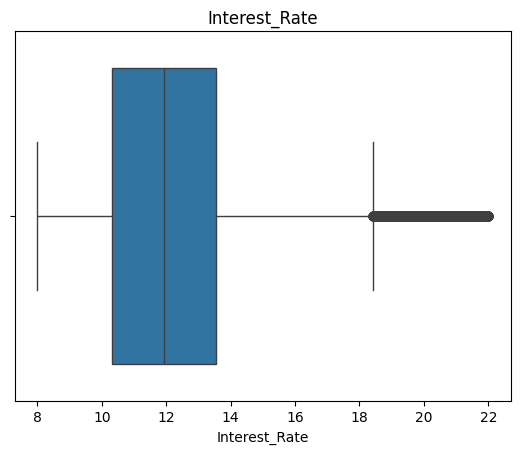

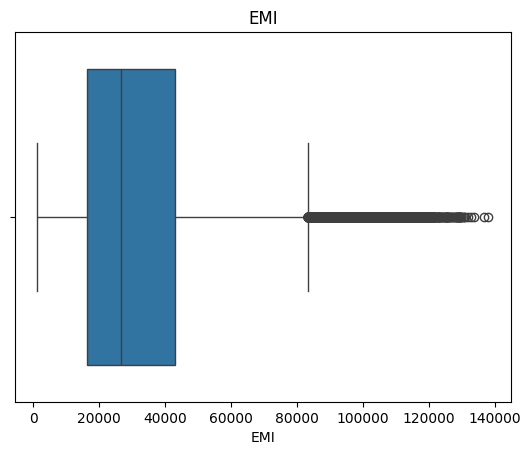

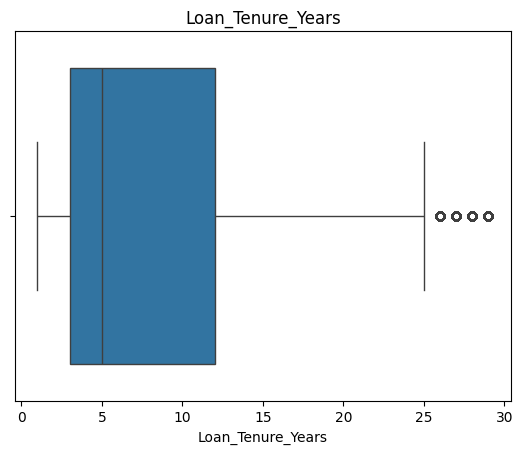

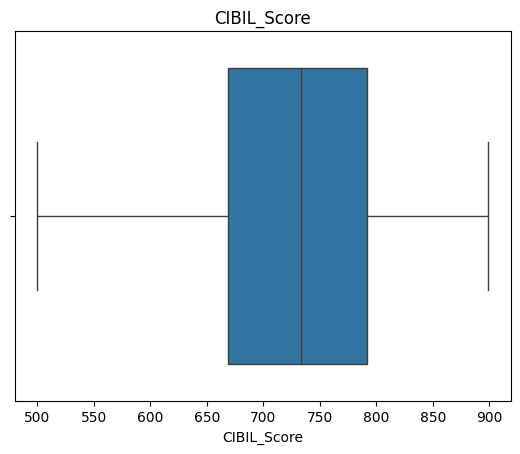

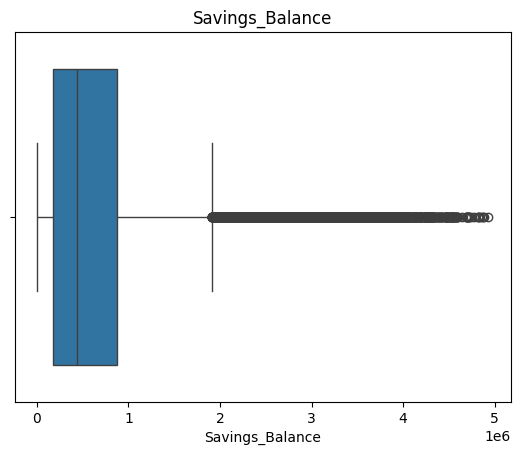

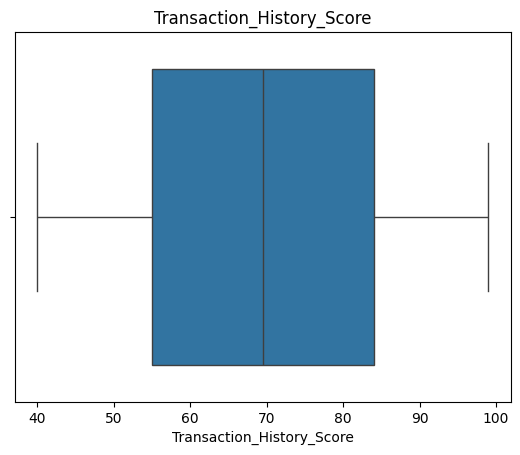

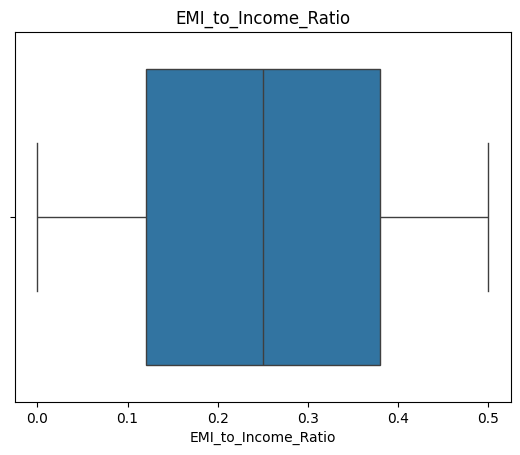

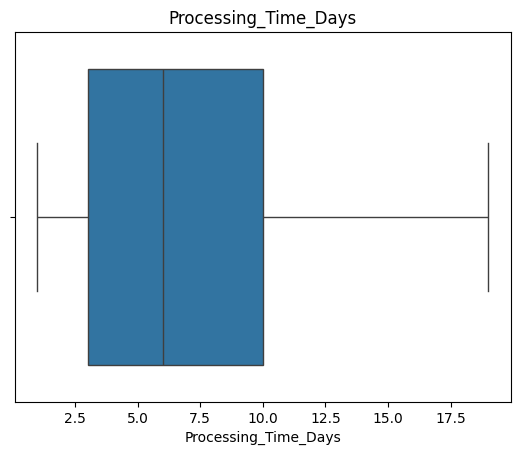

In [31]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()  
    

In [33]:
# ============================================================
# CHECK OUTLIER PERCENTAGE
# ============================================================

def outlier_percentage(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    percentage = (
        len(outliers) / len(df)
    ) * 100

    print(f"{column}")
    print(f"Outliers: {len(outliers)}")
    print(f"Percentage: {percentage:.2f}%")
    print("-" * 40)

columns = [
    'Monthly_Salary',
    'Existing_EMI',
    'Loan_Amount',
    'Savings_Balance',
    'EMI'
]

for col in columns:
    outlier_percentage(col)

Monthly_Salary
Outliers: 3523
Percentage: 4.70%
----------------------------------------
Existing_EMI
Outliers: 2771
Percentage: 3.69%
----------------------------------------
Loan_Amount
Outliers: 10657
Percentage: 14.21%
----------------------------------------
Savings_Balance
Outliers: 2859
Percentage: 3.81%
----------------------------------------
EMI
Outliers: 3459
Percentage: 4.61%
----------------------------------------


#### Decision Rule
| Outlier % | Action     |
| --------- | ---------- |
| < 5%      | Can remove |
| 5–15%     | Cap        |
| > 15%     | Keep       |


In [36]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,75000.0,40.06,11.27,21.00,30.00,40.00,50.00,59.00
Monthly_Salary,75000.0,124006.53,89535.04,2.00,60747.50,111845.50,163203.75,499939.00
Annual_Income,75000.0,1488078.40,1074420.44,24.00,728970.00,1342146.00,1958445.00,5999268.00
Credit_Score,75000.0,726.87,85.51,500.00,669.00,733.00,792.00,899.00
Existing_Loan_Count,75000.0,1.31,1.14,0.00,0.00,1.00,2.00,4.00
Existing_EMI,75000.0,30784.84,31033.08,0.00,8668.00,21910.50,43618.25,248129.00
Years_With_Bank,75000.0,10.00,5.47,1.00,5.00,10.00,15.00,19.00
Loan_Amount,75000.0,2110815.72,2340709.23,50035.00,569783.25,1140410.50,2455897.00,8999957.00
Interest_Rate,75000.0,12.48,3.15,8.00,10.31,11.94,13.55,22.00
EMI,75000.0,32847.52,22959.02,1310.51,16244.67,26679.66,43032.41,138031.05


In [37]:
# ============================================================
# EXISTING EMI OUTLIER CAPPING
# ============================================================

Q1 = df['Existing_EMI'].quantile(0.25)
Q3 = df['Existing_EMI'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Existing_EMI'] = np.clip(
    df['Existing_EMI'],
    lower,
    upper
)

print("Existing_EMI outliers capped")

Existing_EMI outliers capped


In [38]:
# ============================================================
# LOG TRANSFORMATION
# ============================================================

df['Savings_Balance_Log'] = np.log1p(
    df['Savings_Balance']
)

print("Savings_Balance transformed")

Savings_Balance transformed


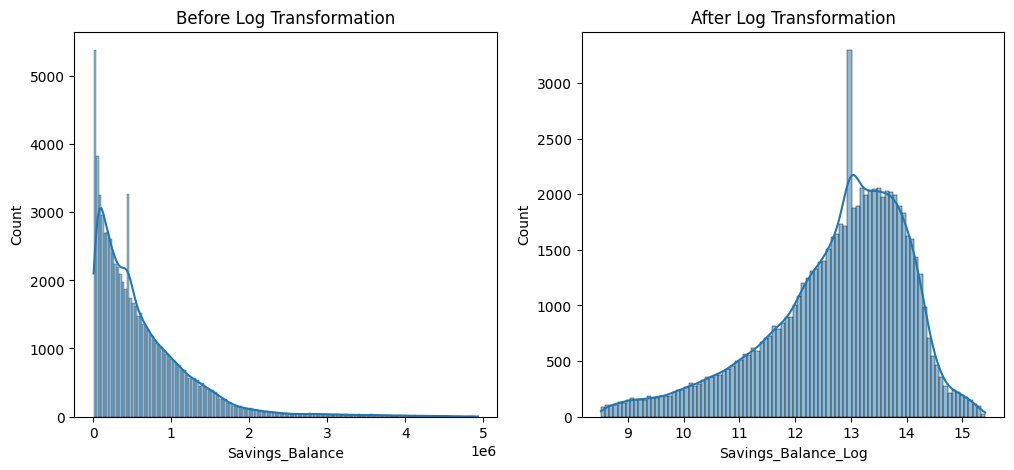

In [39]:
# ============================================================
# BEFORE VS AFTER
# ============================================================

plt.figure(figsize=(12,5))

# Before

plt.subplot(1,2,1)

sns.histplot(
    df['Savings_Balance'],
    kde=True
)

plt.title("Before Log Transformation")

# After

plt.subplot(1,2,2)

sns.histplot(
    df['Savings_Balance_Log'],
    kde=True
)

plt.title("After Log Transformation")

plt.show()

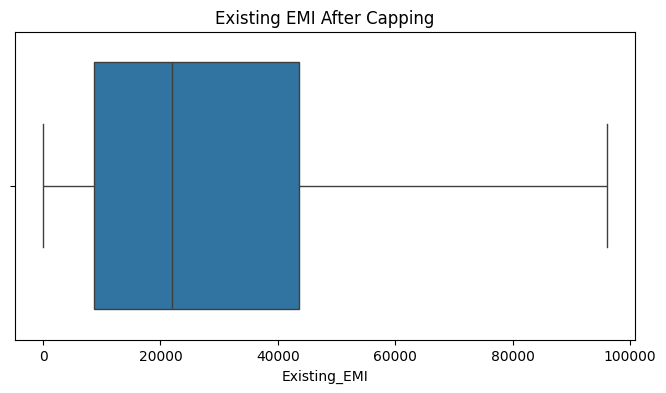

In [40]:
# ============================================================
# CHECK AGAIN
# ============================================================

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Existing_EMI']
)

plt.title("Existing EMI After Capping")

plt.show()

In [42]:
categorical_columns = df.select_dtypes(
    include='object'
).columns

categorical_columns

Index(['Gender', 'Marital_Status', 'Education', 'Employment_Type',
       'Occupation', 'City', 'Area_Type', 'Bank_Account_Type', 'Loan_Type',
       'Property_Ownership', 'Vehicle_Ownership', 'Repayment_History',
       'Loan_Approval_Status', 'Default_Risk', 'Risk_Category'],
      dtype='str')

In [44]:
print(df['Risk_Category'].value_counts())
print(df['Default_Risk'].value_counts())
print(df['Loan_Approval_Status'].value_counts())
print(df['Repayment_History'].value_counts())
print(df['Vehicle_Ownership'].value_counts())
print(df['Property_Ownership'].value_counts())
print(df['Loan_Type'].value_counts())
print(df['Bank_Account_Type'].value_counts())
print(df['Area_Type'].value_counts())
print(df['City'].value_counts())
print(df['Occupation'].value_counts())
print(df['Education'].value_counts())
print(df['Marital_Status'].value_counts())
print(df['Gender'].value_counts())
















Risk_Category
Low Risk       34883
Medium Risk    27243
High Risk      12874
Name: count, dtype: int64
Default_Risk
Low       34883
Medium    27243
High      12874
Name: count, dtype: int64
Loan_Approval_Status
Approved       33191
Conditional    24667
Rejected       17142
Name: count, dtype: int64
Repayment_History
Good         30121
Excellent    21007
Average      16367
Poor          7505
Name: count, dtype: int64
Vehicle_Ownership
Yes    41356
No     33644
Name: count, dtype: int64
Property_Ownership
Rented          29991
Owned           26217
Family Owned    18792
Name: count, dtype: int64
Loan_Type
Car Loan          32479
Home Loan         21486
Personal Loan     17758
Education Loan     3277
Name: count, dtype: int64
Bank_Account_Type
Savings    33493
Salary     30058
Current    11449
Name: count, dtype: int64
Area_Type
Urban         44943
Semi-Urban    22600
Rural          7457
Name: count, dtype: int64
City
Pune    75000
Name: count, dtype: int64
Occupation
Accountant          

In [45]:
# ============================================================
# DROP CITY COLUMN
# ============================================================

df.drop(
    'City',
    axis=1,
    inplace=True
)

print("City column removed")

City column removed


In [46]:
# ============================================================
# DROP RISK CATEGORY
# ============================================================

df.drop(
    'Risk_Category',
    axis=1,
    inplace=True
)

print("Risk_Category removed")

Risk_Category removed


In [47]:
# ============================================================
# ORDINAL ENCODING
# ============================================================

# Repayment History

repayment_mapping = {

    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3

}

df['Repayment_History'] = df[
    'Repayment_History'
].map(repayment_mapping)

# Default Risk

default_mapping = {

    'Low': 0,
    'Medium': 1,
    'High': 2

}

df['Default_Risk'] = df[
    'Default_Risk'
].map(default_mapping)

# Loan Approval

approval_mapping = {

    'Rejected': 0,
    'Conditional': 1,
    'Approved': 2

}

df['Loan_Approval_Status'] = df[
    'Loan_Approval_Status'
].map(approval_mapping)

print("Ordinal Encoding Completed")

Ordinal Encoding Completed


In [48]:
# ============================================================
# LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_columns = [

    'Gender',
    'Marital_Status',
    'Education',
    'Employment_Type',
    'Occupation',
    'Area_Type',
    'Bank_Account_Type',
    'Loan_Type',
    'Property_Ownership',
    'Vehicle_Ownership'

]

for col in label_columns:

    df[col] = le.fit_transform(
        df[col]
    )

print("Label Encoding Completed")

Label Encoding Completed


In [49]:
df.head()

,Age,Gender,Marital_Status,Education,Employment_Type,Occupation,Monthly_Salary,Annual_Income,Area_Type,Credit_Score,...,Vehicle_Ownership,CIBIL_Score,Savings_Balance,Transaction_History_Score,Repayment_History,EMI_to_Income_Ratio,Loan_Approval_Status,Default_Risk,Processing_Time_Days,Savings_Balance_Log
0,59,1,1,2,3,5,227892,2734704,2,714,...,1,714,441928.0,63.0,1,0.49,1,1,8,12.998905
1,48,0,0,2,1,8,201845,2422140,2,754,...,1,754,670987.0,64.0,0,0.06,1,2,6,13.416507
2,55,1,1,2,3,5,39457,473484,2,553,...,0,553,228165.0,75.0,2,0.20,0,2,18,12.337829
3,44,1,2,2,2,1,56044,672528,1,684,...,1,684,485754.0,56.0,1,0.05,2,1,2,13.093460
4,54,1,2,2,3,3,143684,1724208,1,713,...,0,713,1044577.0,94.0,1,0.49,1,1,11,13.859124


In [50]:
X = df.drop('EMI', axis=1)

y = df['EMI']

In [51]:
# ============================================================
# FEATURES & TARGET

print(X.shape)
print(y.shape)

(75000, 29)
(75000,)


In [52]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42

)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (60000, 29)
X_test Shape  : (15000, 29)
y_train Shape : (60000,)
y_test Shape  : (15000,)


In [53]:
# ============================================================
# IMPORT MODEL
# ============================================================

from sklearn.tree import DecisionTreeRegressor

In [54]:
# ============================================================
# CREATE MODEL
# ============================================================

dt_regressor = DecisionTreeRegressor(

    random_state=42

)

In [55]:
# ============================================================
# TRAIN MODEL
# ============================================================

dt_regressor.fit(

    X_train,
    y_train

)

print("Model Training Completed")

Model Training Completed


In [56]:
# ============================================================
# PREDICTION
# ============================================================

y_pred = dt_regressor.predict(X_test)

print(y_pred[:10])

[28823.27 44581.49 67472.96 11046.34 17827.02 26289.93 42907.28 23572.77
  6019.77 14397.63]


### STEP 7 — EVALUATION METRICS

For regression:

| Metric   | Meaning        |
| -------- | -------------- |
| MAE      | Average error  |
| MSE      | Squared error  |
| RMSE     | Root error     |
| R² Score | Model accuracy |


In [57]:
# ============================================================
# IMPORT METRICS
# ============================================================

from sklearn.metrics import (

    mean_absolute_error,
    mean_squared_error,
    r2_score

)

In [58]:
# ============================================================
# EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE  : 535.7786746666667
MSE  : 1057323.04674008
RMSE : 1028.2621488414713
R2 Score : 0.9979983663407844


#### INTERPRETATION
| R² Score  | Meaning   |
| --------- | --------- |
| 0.90+     | Excellent |
| 0.80–0.90 | Very Good |
| 0.70–0.80 | Good      |
| < 0.60    | Weak      |


In [59]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    'Actual_EMI': y_test.values,
    'Predicted_EMI': y_pred

})

comparison.head(10)

,Actual_EMI,Predicted_EMI
0,30636.24,28823.27
1,44302.57,44581.49
2,64375.02,67472.96
3,11091.40,11046.34
4,17986.16,17827.02
5,26722.17,26289.93
6,43630.44,42907.28
7,23669.07,23572.77
8,5874.16,6019.77
9,12691.91,14397.63


In [60]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': dt_regressor.feature_importances_

})

importance = importance.sort_values(

    by='Importance',
    ascending=False

)

importance.head(10)

,Feature,Importance
15,Loan_Amount,0.850801
17,Loan_Tenure_Years,0.122858
16,Interest_Rate,0.025856
0,Age,0.000039
9,Credit_Score,0.000035
22,Transaction_History_Score,0.000034
11,Existing_EMI,0.000032
24,EMI_to_Income_Ratio,0.000030
6,Monthly_Salary,0.000029
5,Occupation,0.000029


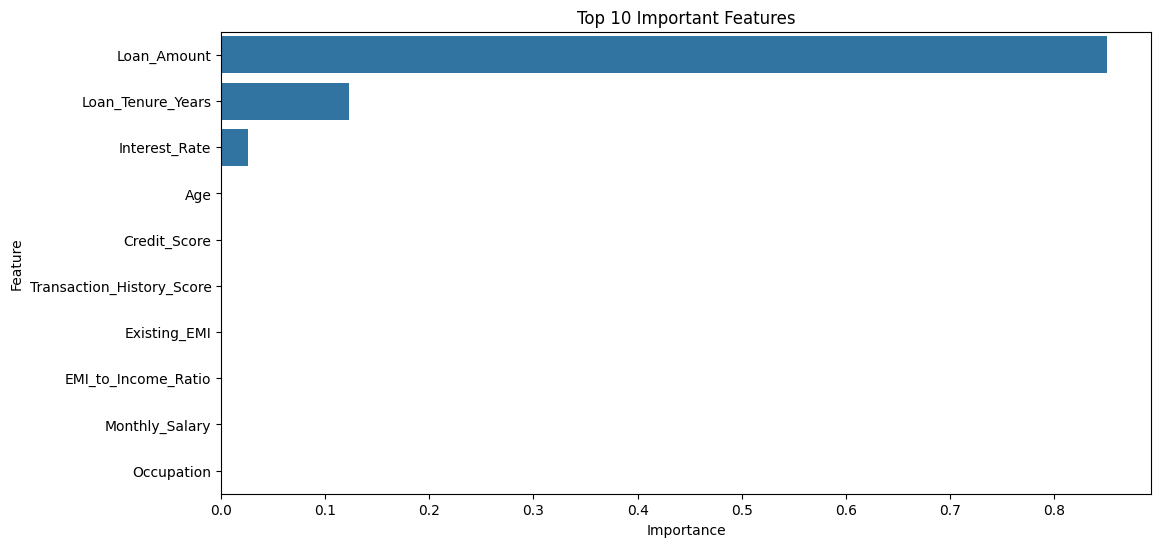

In [61]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    x='Importance',
    y='Feature',

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

In [62]:
# ============================================================
# TRAIN SCORE
# ============================================================

train_score = dt_regressor.score(
    X_train,
    y_train
)

test_score = dt_regressor.score(
    X_test,
    y_test
)

print("Train Score :", train_score)
print("Test Score  :", test_score)

Train Score : 1.0
Test Score  : 0.9979983663407844


| Condition               | Meaning      |
| ----------------------- | ------------ |
| Train = 99%, Test = 75% | Overfitting  |
| Train ≈ Test            | Good model   |
| Both low                | Underfitting |


 — REMOVE LEAKAGE FEATURES (BEST PRACTICE)

This creates realistic ML challenge.

Remove:

Loan_Amount

Interest_Rate

Loan_Tenure_Years

Then predict EMI using:

salary

CIBIL

employment

approval status

savings

liabilities

This becomes real ML.

Feature Shape : (75000, 26)
Target Shape : (75000,)


X_train : (60000, 26)
X_test  : (15000, 26)
y_train : (60000,)
y_test  : (15000,)


Model Training Completed


MODEL PERFORMANCE
MAE  : 14507.819073300076
MSE  : 358797587.7955319
RMSE : 18941.953114595442
R2 Score : 0.3207550608196883


OVERFITTING CHECK
Train Score : 0.5530453641782731
Test Score  : 0.3207550608196883


ACTUAL VS PREDICTED
   Actual_EMI  Predicted_EMI
0    30636.24   55148.365385
1    44302.57   20349.187045
2    64375.02   60006.138066
3    11091.40   21293.003449
4    17986.16   27663.706522
5    26722.17   28276.658889
6    43630.44   53863.601739
7    23669.07   14882.260000
8     5874.16   11409.525000
9    12691.91   27733.947917


TOP 10 IMPORTANT FEATURES
                      Feature  Importance
14                  Loan_Type    0.328856
9                Credit_Score    0.266282
6              Monthly_Salary    0.192167
17                CIBIL_Score    0.024216
11               Existing_EMI    0.022700
19 

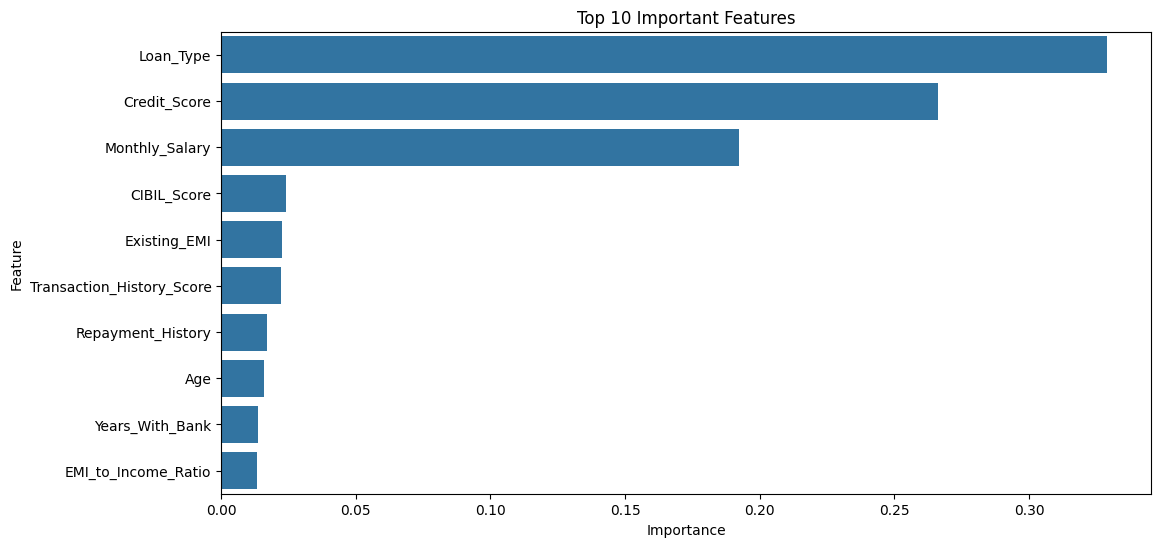

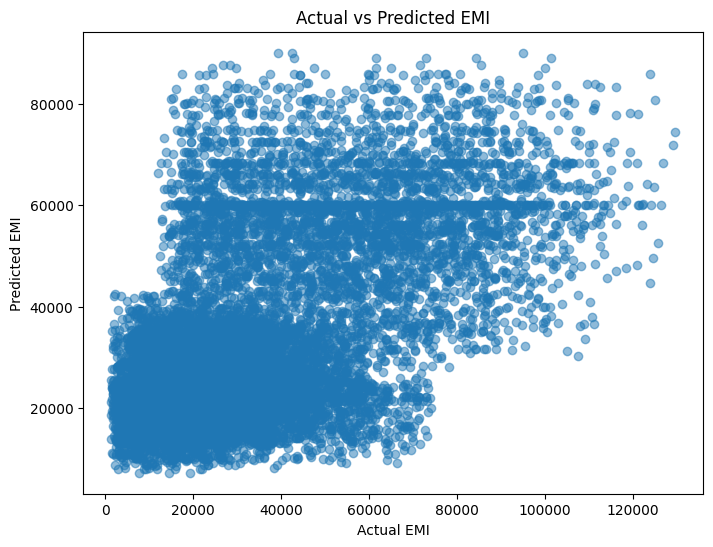

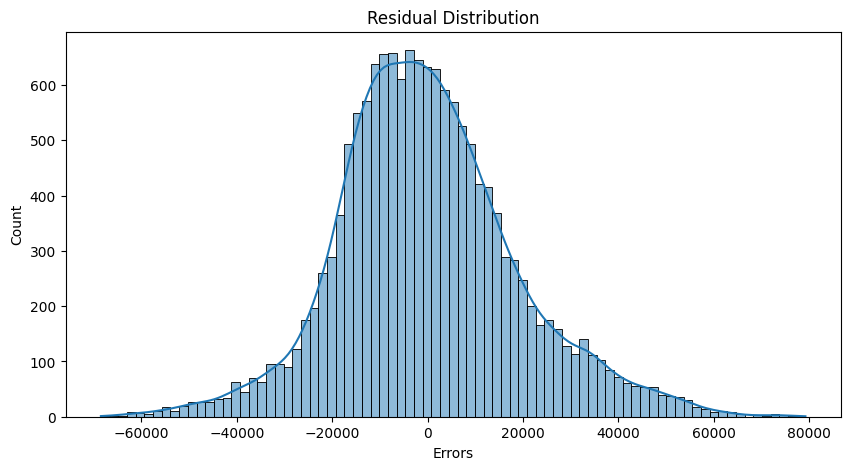



Prediction file saved successfully
File Name : emi_predictions.csv


In [65]:
# ============================================================
# EMI PREDICTION USING DECISION TREE REGRESSOR
# (WITHOUT TARGET LEAKAGE)
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (

    mean_absolute_error,
    mean_squared_error,
    r2_score

)

# ============================================================
# FEATURES & TARGET
# ============================================================

# Removing leakage columns

X = df.drop(

    [
        'EMI',
        'Loan_Amount',
        'Interest_Rate',
        'Loan_Tenure_Years'
    ],

    axis=1

)

# Target

y = df['EMI']

# ============================================================
# CHECK SHAPES
# ============================================================

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

# ============================================================
# SHAPES
# ============================================================

print("\n")

print("X_train :", X_train.shape)

print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test  :", y_test.shape)

# ============================================================
# CREATE MODEL
# ============================================================

dt_regressor = DecisionTreeRegressor(

    random_state=42,

    max_depth=20,

    min_samples_split=30,

    min_samples_leaf=15

)

# ============================================================
# TRAIN MODEL
# ============================================================

dt_regressor.fit(

    X_train,
    y_train

)

print("\n")

print("Model Training Completed")

# ============================================================
# PREDICTION
# ============================================================

y_pred = dt_regressor.predict(X_test)

# ============================================================
# EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

# ============================================================
# PRINT METRICS
# ============================================================

print("\n")

print("=" * 50)

print("MODEL PERFORMANCE")

print("=" * 50)

print(f"MAE  : {mae}")

print(f"MSE  : {mse}")

print(f"RMSE : {rmse}")

print(f"R2 Score : {r2}")

# ============================================================
# TRAIN & TEST SCORE
# ============================================================

train_score = dt_regressor.score(

    X_train,
    y_train

)

test_score = dt_regressor.score(

    X_test,
    y_test

)

print("\n")

print("=" * 50)

print("OVERFITTING CHECK")

print("=" * 50)

print(f"Train Score : {train_score}")

print(f"Test Score  : {test_score}")

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    'Actual_EMI': y_test.values,

    'Predicted_EMI': y_pred

})

print("\n")

print("=" * 50)

print("ACTUAL VS PREDICTED")

print("=" * 50)

print(comparison.head(10))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': dt_regressor.feature_importances_

})

importance = importance.sort_values(

    by='Importance',
    ascending=False

)

print("\n")

print("=" * 50)

print("TOP 10 IMPORTANT FEATURES")

print("=" * 50)

print(importance.head(10))

# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

# ============================================================
# ACTUAL VS PREDICTED SCATTERPLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,
    y_pred,
    alpha=0.5

)

plt.xlabel("Actual EMI")

plt.ylabel("Predicted EMI")

plt.title("Actual vs Predicted EMI")

plt.show()

# ============================================================
# RESIDUALS
# ============================================================

residuals = y_test - y_pred

# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(

    residuals,
    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Errors")

plt.show()

# ============================================================
# SAVE PREDICTIONS
# ============================================================

comparison.to_csv(

    "emi_predictions.csv",

    index=False

)

print("\n")

print("Prediction file saved successfully")

print("File Name : emi_predictions.csv")

DATA SHAPES
X_train : (60000, 27)
X_test  : (15000, 27)
y_train : (60000,)
y_test  : (15000,)
Fitting 3 folds for each of 16 candidates, totalling 48 fits


BEST PARAMETERS
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


MODEL PERFORMANCE
MAE  : 6078.472396476009
MSE  : 69858741.97230822
RMSE : 8358.154220419017
R2 Score : 0.8677493981112421


OVERFITTING CHECK
Train Score : 0.892211163580036
Test Score  : 0.8677493981112421


ACTUAL VS PREDICTED
   Actual_EMI  Predicted_EMI
0    30636.24   27700.400431
1    44302.57   22901.933317
2    64375.02   68827.129775
3    11091.40    6239.666566
4    17986.16   28167.152790
5    26722.17   30828.184493
6    43630.44   48244.165821
7    23669.07   35990.638451
8     5874.16    2920.109886
9    12691.91   16276.664822


TOP 10 IMPORTANT FEATURES
                      Feature  Importance
15                Loan_Amount    0.922381
14                  Loan_Type    0.038786
21          Repayment_History    0.

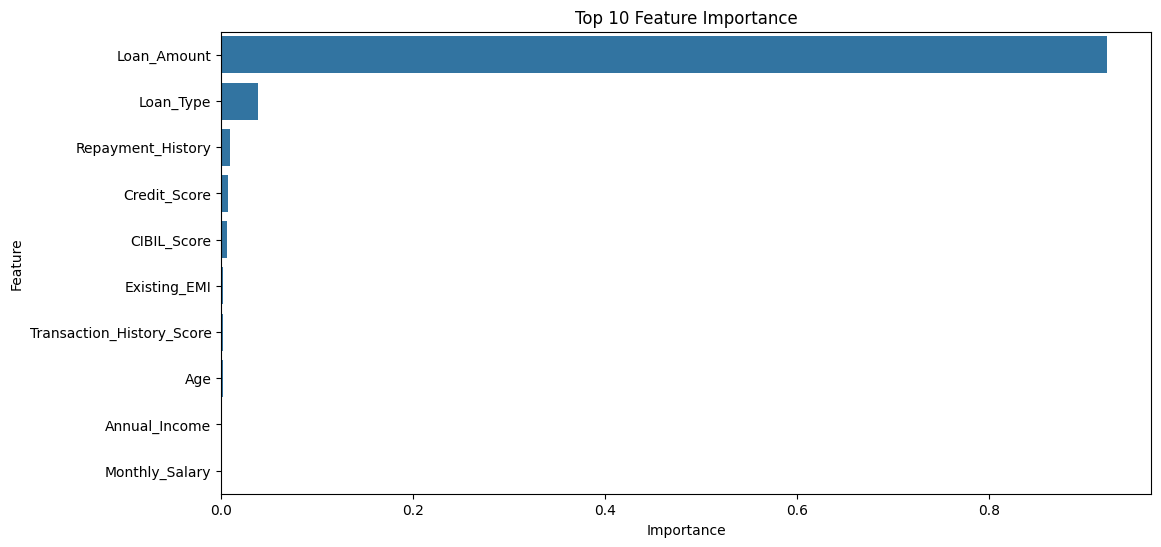

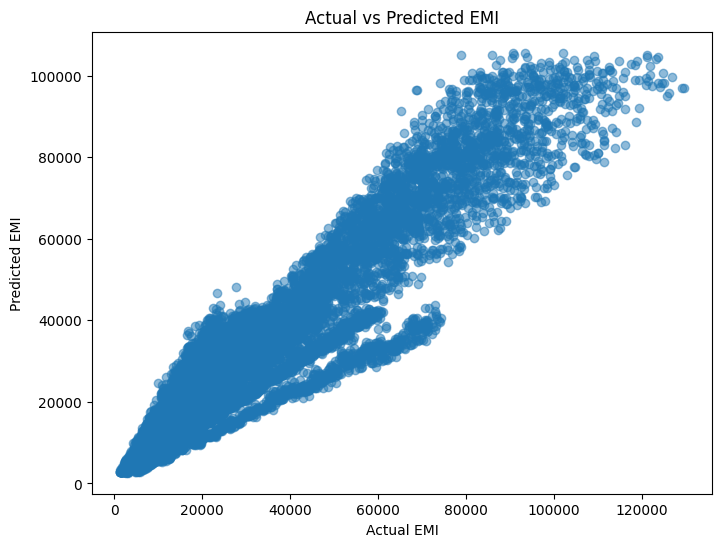

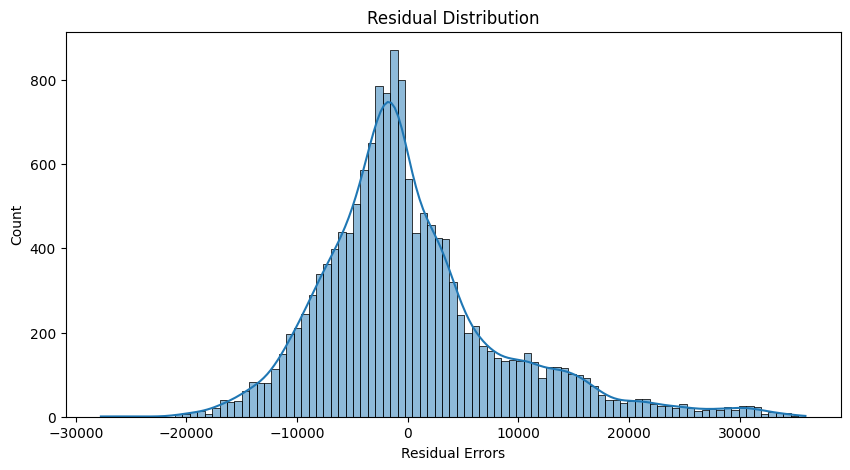



FILE SAVED SUCCESSFULLY
File Name : rf_emi_predictions.csv


In [66]:
# ============================================================
# RANDOM FOREST REGRESSOR WITH HYPERPARAMETER TUNING
# EMI PREDICTION PROJECT
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (

    train_test_split,
    GridSearchCV

)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (

    mean_absolute_error,
    mean_squared_error,
    r2_score

)

# ============================================================
# FEATURES & TARGET
# ============================================================

# Removing leakage columns

X = df.drop(

    [
        'EMI',
        'Interest_Rate',
        'Loan_Tenure_Years'
    ],

    axis=1

)

# Target

y = df['EMI']

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

# ============================================================
# SHAPES
# ============================================================

print("=" * 50)

print("DATA SHAPES")

print("=" * 50)

print("X_train :", X_train.shape)

print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test  :", y_test.shape)

# ============================================================
# CREATE BASE MODEL
# ============================================================

rf = RandomForestRegressor(

    random_state=42,

    n_jobs=-1

)

# ============================================================
# HYPERPARAMETER GRID
# ============================================================

param_grid = {

    'n_estimators': [100, 150],

    'max_depth': [10, 15],

    'min_samples_split': [5, 10],

    'min_samples_leaf': [2, 4]

}

# ============================================================
# GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    verbose=2,

    n_jobs=-1

)

# ============================================================
# TRAIN GRID SEARCH
# ============================================================

grid_search.fit(

    X_train,
    y_train

)

print("\n")

print("=" * 50)

print("BEST PARAMETERS")

print("=" * 50)

print(grid_search.best_params_)

# ============================================================
# BEST MODEL
# ============================================================

best_rf = grid_search.best_estimator_

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = best_rf.predict(X_test)

# ============================================================
# EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(

    y_test,
    y_pred

)

mse = mean_squared_error(

    y_test,
    y_pred

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,
    y_pred

)

# ============================================================
# PRINT PERFORMANCE
# ============================================================

print("\n")

print("=" * 50)

print("MODEL PERFORMANCE")

print("=" * 50)

print(f"MAE  : {mae}")

print(f"MSE  : {mse}")

print(f"RMSE : {rmse}")

print(f"R2 Score : {r2}")

# ============================================================
# TRAIN & TEST SCORE
# ============================================================

train_score = best_rf.score(

    X_train,
    y_train

)

test_score = best_rf.score(

    X_test,
    y_test

)

print("\n")

print("=" * 50)

print("OVERFITTING CHECK")

print("=" * 50)

print(f"Train Score : {train_score}")

print(f"Test Score  : {test_score}")

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    'Actual_EMI': y_test.values,

    'Predicted_EMI': y_pred

})

print("\n")

print("=" * 50)

print("ACTUAL VS PREDICTED")

print("=" * 50)

print(comparison.head(10))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',
    ascending=False

)

print("\n")

print("=" * 50)

print("TOP 10 IMPORTANT FEATURES")

print("=" * 50)

print(importance.head(10))

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)

)

plt.title("Top 10 Feature Importance")

plt.show()

# ============================================================
# ACTUAL VS PREDICTED SCATTERPLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,
    y_pred,
    alpha=0.5

)

plt.xlabel("Actual EMI")

plt.ylabel("Predicted EMI")

plt.title("Actual vs Predicted EMI")

plt.show()

# ============================================================
# RESIDUALS
# ============================================================

residuals = y_test - y_pred

# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(

    residuals,
    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Residual Errors")

plt.show()

# ============================================================
# SAVE PREDICTIONS
# ============================================================

comparison.to_csv(

    "rf_emi_predictions.csv",

    index=False

)

print("\n")

print("=" * 50)

print("FILE SAVED SUCCESSFULLY")

print("=" * 50)

print("File Name : rf_emi_predictions.csv")

#### Random Forest Regressor achieved an R² score of 86.7% for EMI prediction, demonstrating strong capability in learning nonlinear financial relationships within the banking loan dataset.

# Random Forest Classifier for predict Loan approval status

DATA SHAPES
Feature Shape : (75000, 27)
Target Shape  : (75000,)


X_train : (60000, 27)
X_test  : (15000, 27)
y_train : (60000,)
y_test  : (15000,)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


MODEL TRAINING COMPLETED


BEST PARAMETERS
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


MODEL PERFORMANCE
Accuracy  : 0.9705333333333334
Precision : 0.9707095021205409
Recall    : 0.9705333333333334
F1 Score  : 0.9704241302989289


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      3428
           1       0.95      0.98      0.97      4934
           2       0.98      0.99      0.98      6638

    accuracy                           0.97     15000
   macro avg       0.97      0.96      0.97     15000
weighted avg       0.97      0.97      0.97     15000



CONFUSION MATRIX
[[3183  171   74]
 [  43 4823   68]
 [  29   57 6552]]


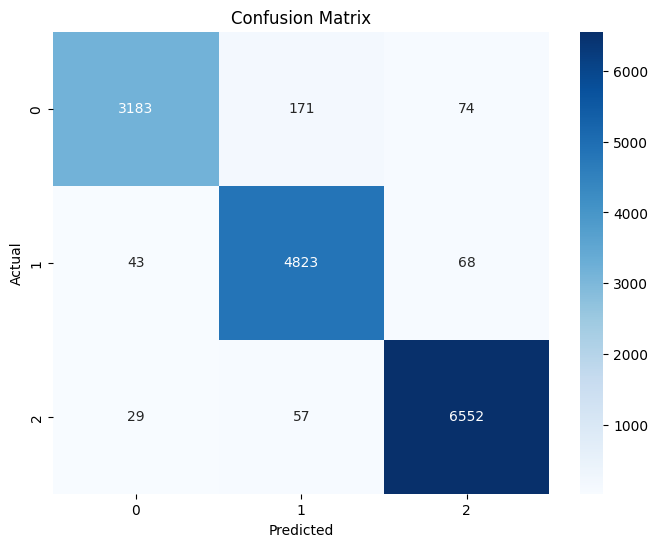



TOP 10 IMPORTANT FEATURES
                 Feature  Importance
25  Processing_Time_Days    0.462660
23     Repayment_History    0.061966
9           Credit_Score    0.057550
20           CIBIL_Score    0.055071
6         Monthly_Salary    0.050372
14             Loan_Type    0.048104
10   Existing_Loan_Count    0.042790
7          Annual_Income    0.040992
24   EMI_to_Income_Ratio    0.033305
21       Savings_Balance    0.029312


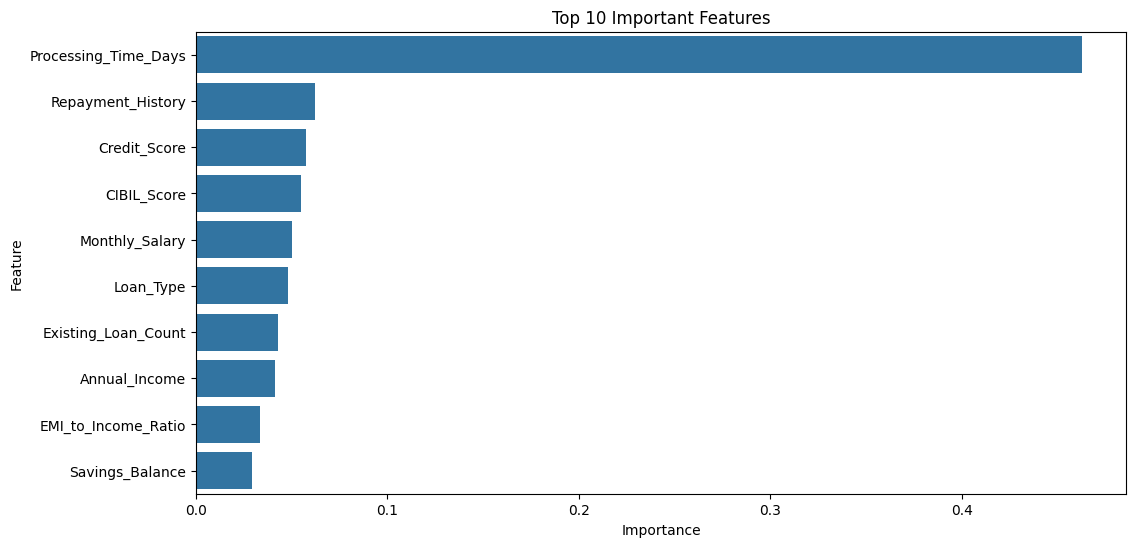



ACTUAL VS PREDICTED
   Actual_Status  Predicted_Status
0              2                 2
1              1                 1
2              1                 1
3              2                 2
4              2                 2
5              0                 0
6              2                 2
7              2                 2
8              2                 2
9              2                 2


FILE SAVED SUCCESSFULLY
File Name : loan_approval_predictions.csv


In [76]:
# ============================================================
# RANDOM FOREST CLASSIFIER
# LOAN APPROVAL STATUS PREDICTION
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (

    train_test_split,
    GridSearchCV

)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score

)

# ============================================================
# FEATURES & TARGET
# ============================================================

# TARGET VARIABLE

y = df['Loan_Approval_Status']

# ============================================================
# REMOVE TARGET LEAKAGE COLUMNS
# ============================================================

X = df.drop(

    [
        'Loan_Approval_Status',
        'Default_Risk',
        'EMI'
    ],

    axis=1

)

# ============================================================
# CHECK SHAPES
# ============================================================

print("=" * 50)

print("DATA SHAPES")

print("=" * 50)

print("Feature Shape :", X.shape)

print("Target Shape  :", y.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# ============================================================
# SHAPES
# ============================================================

print("\n")

print("X_train :", X_train.shape)

print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test  :", y_test.shape)

# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

rf_classifier = RandomForestClassifier(

    random_state=42,

    n_jobs=-1

)

# ============================================================
# HYPERPARAMETER GRID
# ============================================================

param_grid = {

    'n_estimators': [100],

    'max_depth': [10, 15],

    'min_samples_split': [5, 10],

    'min_samples_leaf': [2, 4]

}

# ============================================================
# GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(

    estimator=rf_classifier,

    param_grid=param_grid,

    cv=3,

    scoring='accuracy',

    verbose=2,

    n_jobs=-1

)

# ============================================================
# TRAIN MODEL
# ============================================================

grid_search.fit(

    X_train,
    y_train

)

print("\n")

print("=" * 50)

print("MODEL TRAINING COMPLETED")

print("=" * 50)

# ============================================================
# BEST PARAMETERS
# ============================================================

print("\n")

print("=" * 50)

print("BEST PARAMETERS")

print("=" * 50)

print(grid_search.best_params_)

# ============================================================
# BEST MODEL
# ============================================================

best_rf = grid_search.best_estimator_

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = best_rf.predict(X_test)

# ============================================================
# PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(

    y_test,
    y_pred

)

precision = precision_score(

    y_test,
    y_pred,

    average='weighted'

)

recall = recall_score(

    y_test,
    y_pred,

    average='weighted'

)

f1 = f1_score(

    y_test,
    y_pred,

    average='weighted'

)

# ============================================================
# PRINT PERFORMANCE
# ============================================================

print("\n")

print("=" * 50)

print("MODEL PERFORMANCE")

print("=" * 50)

print(f"Accuracy  : {accuracy}")

print(f"Precision : {precision}")

print(f"Recall    : {recall}")

print(f"F1 Score  : {f1}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")

print("=" * 50)

print("CLASSIFICATION REPORT")

print("=" * 50)

print(

    classification_report(

        y_test,
        y_pred

    )

)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,
    y_pred

)

print("\n")

print("=" * 50)

print("CONFUSION MATRIX")

print("=" * 50)

print(cm)

# ============================================================
# CONFUSION MATRIX HEATMAP
# ============================================================

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',
    ascending=False

)

# ============================================================
# TOP FEATURES
# ============================================================

print("\n")

print("=" * 50)

print("TOP 10 IMPORTANT FEATURES")

print("=" * 50)

print(importance.head(10))

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    'Actual_Status': y_test.values,

    'Predicted_Status': y_pred

})

print("\n")

print("=" * 50)

print("ACTUAL VS PREDICTED")

print("=" * 50)

print(comparison.head(10))

# ============================================================
# SAVE PREDICTIONS
# ============================================================

comparison.to_csv(

    "loan_approval_predictions.csv",

    index=False

)

print("\n")

print("=" * 50)

print("FILE SAVED SUCCESSFULLY")

print("=" * 50)

print("File Name : loan_approval_predictions.csv")

### Loan Approval Status Prediction — Model Explanation
#### Project Objective

##### The objective of this project was to build a machine learning classification model capable of predicting the loan approval status of customers in a realistic Indian banking environment using customer financial, employment, and banking history data.

#### The dataset was designed to simulate real-world loan approval behavior followed by Indian banks.

In [77]:
# ============================================================
# SAVE RANDOM FOREST MODEL
# ============================================================

import joblib

joblib.dump(

    best_rf,

    "loan_approval_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [79]:
importance.head(10)

,Feature,Importance
25,Processing_Time_Days,0.462660
23,Repayment_History,0.061966
9,Credit_Score,0.057550
20,CIBIL_Score,0.055071
6,Monthly_Salary,0.050372
14,Loan_Type,0.048104
10,Existing_Loan_Count,0.042790
7,Annual_Income,0.040992
24,EMI_to_Income_Ratio,0.033305
21,Savings_Balance,0.029312
